In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

import medmnist
from medmnist import INFO

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Device: cpu


In [ ]:
# Dataset information
data_flag = "octmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

print("Dataset:", info["description"])
print("Task:", info["task"])
print("Number of classes:", len(info["label"]))
print("Labels:", info["label"])

# Transform images to tensors and normalise to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = DataClass(split="train", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Dataset: The OCTMNIST is based on a prior dataset of 109,309 valid optical coherence tomography (OCT) images for retinal diseases. The dataset is comprised of 4 diagnosis categories, leading to a multi-class classification task. We split the source training set with a ratio of 9:1 into training and validation set, and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−1,536)×(277−512). We center-crop the images and resize them into 1×28×28.
Task: multi-class
Number of classes: 4
Labels: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}


100%|██████████| 54.9M/54.9M [00:46<00:00, 1.19MB/s]


Training samples: 97477
Test samples: 1000


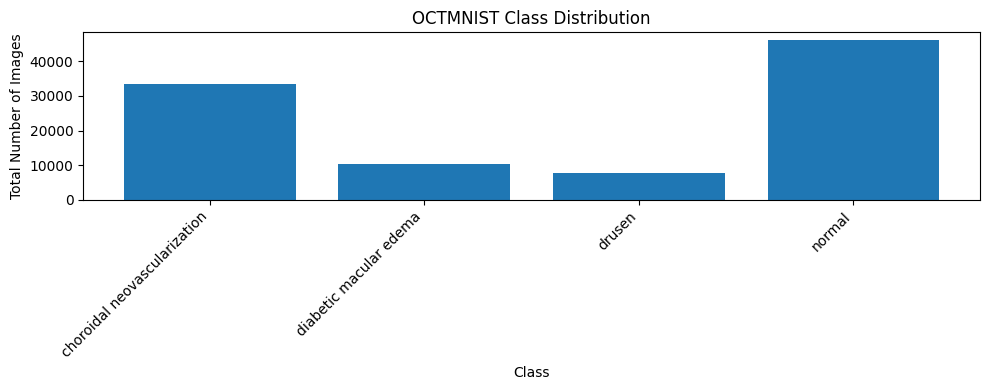

Classes: ['choroidal neovascularization', 'diabetic macular edema', 'drusen', 'normal']
Counts : [33484, 10213, 7754, 46026]


In [ ]:
labels = train_dataset.labels.flatten()
class_count = Counter(labels)

class_names = [info["label"][str(i)] for i in range(len(info["label"]))]

plt.figure(figsize=(10, 4))
plt.bar(class_names, [class_count[i] for i in range(len(class_names))])
plt.xticks(rotation=45, ha="right")
plt.title("OCTMNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Total Number of Images")
plt.tight_layout()
plt.show()

print("Classes:", class_names)
counts = [class_count[i] for i in range(len(class_names))]
print("Counts :",counts)


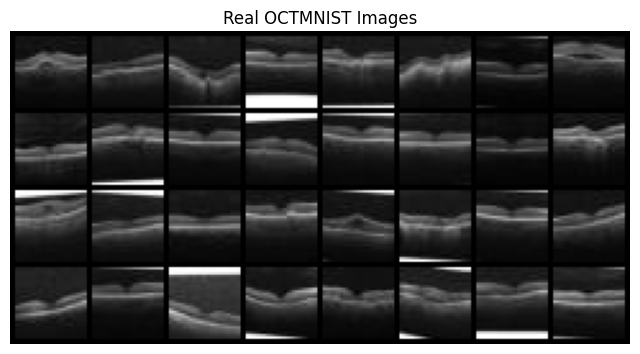

In [ ]:
real_batch, real_labels = next(iter(train_loader))
real_display = (real_batch[:32] + 1) / 2

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real OCTMNIST Images")
plt.imshow(
    np.transpose(vutils.make_grid(real_display, nrow=8, padding=2).numpy(), (1, 2, 0))
)
plt.show()

In [ ]:
#checking the shape
image, label = train_dataset[0]
print("Image Shape :", image.shape)
print("Label :", label)

Image Shape : torch.Size([1, 28, 28])
Label : [0]


In [ ]:
z_dim = 100
image_channels = 1

class DCGANGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # z: 100 x 1 x 1
            nn.ConvTranspose2d(z_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 7 x 7
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 14 x 14
            nn.ConvTranspose2d(64, image_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # input: 3 x 28 x 28
            nn.Conv2d(image_channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 14 x 14
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 7 x 7
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Epoch 1/30 | D Loss: 0.5092 | G Loss: 2.2407
Epoch 2/30 | D Loss: 0.4349 | G Loss: 2.3973
Epoch 3/30 | D Loss: 0.3785 | G Loss: 2.6635
Epoch 4/30 | D Loss: 0.3911 | G Loss: 2.7083
Epoch 5/30 | D Loss: 0.3968 | G Loss: 2.8237
Epoch 6/30 | D Loss: 0.4227 | G Loss: 2.6771
Epoch 7/30 | D Loss: 0.4315 | G Loss: 2.6630
Epoch 8/30 | D Loss: 0.3609 | G Loss: 3.0747
Epoch 9/30 | D Loss: 0.3518 | G Loss: 3.0440
Epoch 10/30 | D Loss: 0.4092 | G Loss: 2.9010


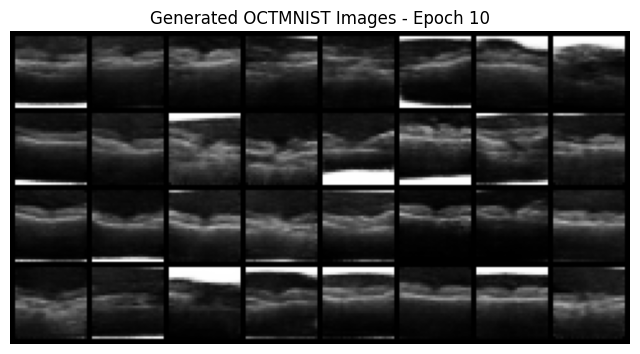

Epoch 11/30 | D Loss: 0.3855 | G Loss: 2.6920
Epoch 12/30 | D Loss: 0.3752 | G Loss: 2.9825
Epoch 13/30 | D Loss: 0.3511 | G Loss: 3.2383
Epoch 14/30 | D Loss: 0.3526 | G Loss: 3.0944
Epoch 15/30 | D Loss: 0.3465 | G Loss: 3.3511
Epoch 16/30 | D Loss: 0.3302 | G Loss: 3.2295
Epoch 17/30 | D Loss: 0.3197 | G Loss: 3.4898
Epoch 18/30 | D Loss: 0.3145 | G Loss: 3.3146
Epoch 19/30 | D Loss: 0.3240 | G Loss: 3.4276
Epoch 20/30 | D Loss: 0.3145 | G Loss: 3.4031


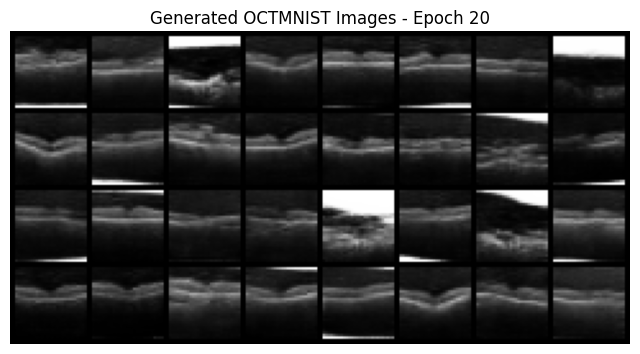

Epoch 21/30 | D Loss: 0.3765 | G Loss: 3.1972
Epoch 22/30 | D Loss: 0.3185 | G Loss: 3.4419
Epoch 23/30 | D Loss: 0.3122 | G Loss: 3.4412
Epoch 24/30 | D Loss: 0.2988 | G Loss: 3.5434
Epoch 25/30 | D Loss: 0.2868 | G Loss: 3.6213
Epoch 26/30 | D Loss: 0.3428 | G Loss: 3.2992
Epoch 26/30 | D Loss: 0.3428 | G Loss: 3.2992
Epoch 27/30 | D Loss: 0.3077 | G Loss: 3.5769
Epoch 27/30 | D Loss: 0.3077 | G Loss: 3.5769
Epoch 28/30 | D Loss: 0.3085 | G Loss: 3.6837
Epoch 28/30 | D Loss: 0.3085 | G Loss: 3.6837
Epoch 29/30 | D Loss: 0.2945 | G Loss: 3.4716
Epoch 29/30 | D Loss: 0.2945 | G Loss: 3.4716
Epoch 30/30 | D Loss: 0.3056 | G Loss: 3.6880
Epoch 30/30 | D Loss: 0.3056 | G Loss: 3.6880


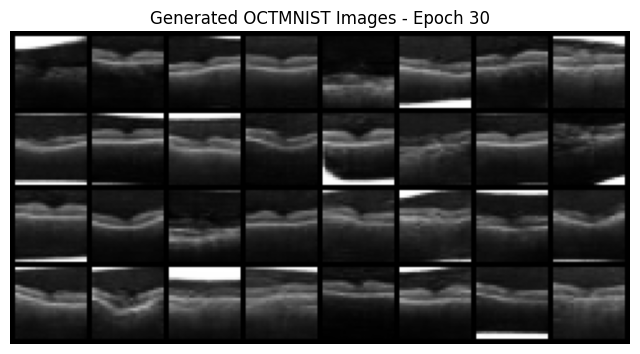

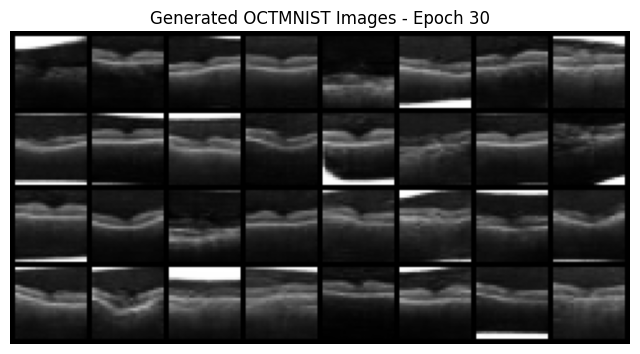

In [ ]:
Gen = DCGANGenerator().to(device)
Dis = DCGANDiscriminator().to(device)

loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(Gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(Dis.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 30

g_losses = []
d_losses = []

for epoch in range(epochs):
    total_g = 0
    total_d = 0

    for real, _ in train_loader:
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Training discriminator
        z = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = Gen(z)

        D_real = Dis(real)
        D_fake = Dis(fake.detach())

        d_loss_real = loss_fn(D_real, real_labels)
        d_loss_fake = loss_fn(D_fake, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Training generator
        z = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = Gen(z)

        D_fake = Dis(fake)
        g_loss = loss_fn(D_fake, real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        total_g += g_loss.item()
        total_d += d_loss.item()

    g_losses.append(total_g / len(train_loader))
    d_losses.append(total_d / len(train_loader))

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

    # Showing the generated images every 10 epochs
    if (epoch + 1) % 10 == 0:
        Gen.eval()
        with torch.no_grad():
            z = torch.randn(32, z_dim, 1, 1).to(device)
            fake_images = Gen(z).cpu()
        fake_display = (fake_images + 1) / 2

        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated OCTMNIST Images - Epoch {epoch+1}")
        plt.imshow(
            np.transpose(vutils.make_grid(fake_display, nrow=8, padding=2).numpy(), (1, 2, 0))
        )
        plt.show()
        Gen.train()

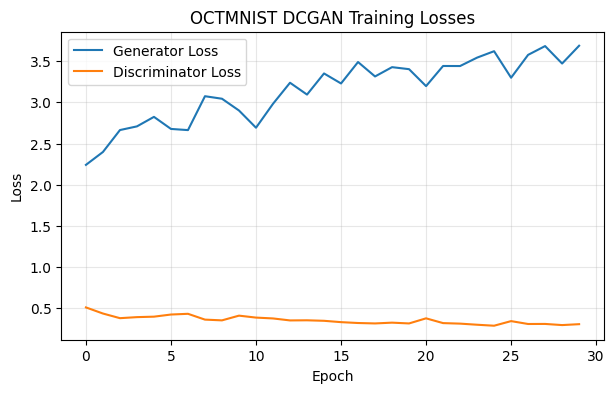

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.title("OCTMNIST DCGAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

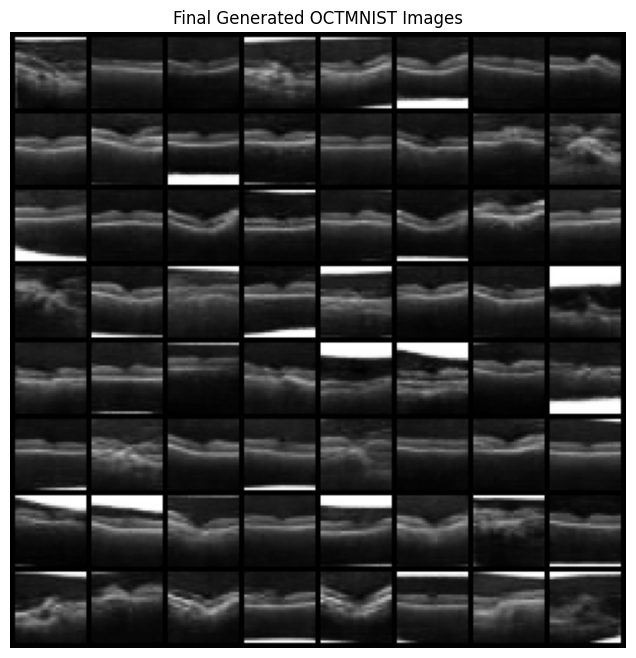

In [ ]:
with torch.no_grad():
    z = torch.randn(64, z_dim, 1, 1).to(device)
    fake_img = Gen(z).cpu()

fake_dis = (fake_img + 1) / 2

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Final Generated OCTMNIST Images")
plt.imshow(
    np.transpose(vutils.make_grid(fake_dis, nrow=8, padding=2).numpy(), (1, 2, 0))
)
plt.show()

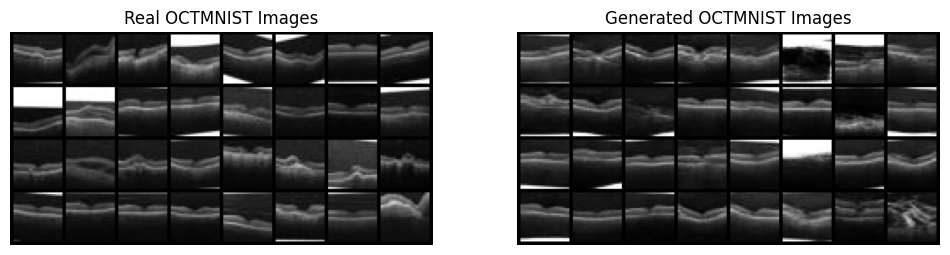

In [ ]:
real_batch, _ = next(iter(train_loader))
real_dis = (real_batch[:32] + 1) / 2

with torch.no_grad():
    z = torch.randn(32, z_dim, 1, 1).to(device)
    fake_batch = Gen(z).cpu()

fake_dis = (fake_batch + 1) / 2

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real OCTMNIST Images")
plt.imshow(
    np.transpose(vutils.make_grid(real_dis, nrow=8, padding=2).numpy(), (1, 2, 0))
)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated OCTMNIST Images")
plt.imshow(
    np.transpose(vutils.make_grid(fake_dis, nrow=8, padding=2).numpy(), (1, 2, 0))
)

plt.show()

In [ ]:
!pip install torchmetrics[image] torch-fidelity -q

from torchmetrics.image.fid import FrechetInceptionDistance
import torch.nn.functional as F

fid = FrechetInceptionDistance(feature=64).to(device)

Gen.eval()

num_batches = 10

with torch.no_grad():
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)

        # Generate fake images
        z = torch.randn(real.size(0), z_dim, 1, 1).to(device)
        fake = Gen(z)

        real = real.repeat(1, 3, 1, 1)
        fake = fake.repeat(1, 3, 1, 1)

        # Converting from [-1, 1] to [0, 255]
        real_uint8 = ((real + 1) * 127.5).clamp(0, 255).to(torch.uint8)
        fake_uint8 = ((fake + 1) * 127.5).clamp(0, 255).to(torch.uint8)

        fid.update(real_uint8, real=True)
        fid.update(fake_uint8, real=False)

        if i + 1 == num_batches:
            break

fid_score = fid.compute().item()
print("FID Score:", fid_score)

FID Score: 0.02289254404604435


In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch.nn.functional as F

fid = FrechetInceptionDistance(feature=768).to(device)

Gen.eval()

num_batches = 10

with torch.no_grad():
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)

        # Generate fake images
        z = torch.randn(real.size(0), z_dim, 1, 1).to(device)
        fake = Gen(z)

        real = real.repeat(1, 3, 1, 1)
        fake = fake.repeat(1, 3, 1, 1)

        # Converting from [-1, 1] to [0, 255]
        real_uint8 = ((real + 1) * 127.5).clamp(0, 255).to(torch.uint8)
        fake_uint8 = ((fake + 1) * 127.5).clamp(0, 255).to(torch.uint8)

        fid.update(real_uint8, real=True)
        fid.update(fake_uint8, real=False)

        if i + 1 == num_batches:
            break

fid_score = fid.compute().item()
print("FID Score:", fid_score)

FID Score: 0.17781710624694824


In [ ]:
real_images = []
fake_images_list = []
with torch.no_grad():
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)

        z = torch.randn(real.size(0), z_dim, 1, 1).to(device)
        fake = Gen(z)

        real_images.append(real.cpu())
        fake_images_list.append(fake.cpu())

        if i == 10:
            break

real_images = torch.cat(real_images, dim=0)
fake_images_tensor = torch.cat(fake_images_list, dim=0)

real_mean = real_images.mean(dim=0)
fake_mean = fake_images_tensor.mean(dim=0)

mean_absolute_difference = torch.mean(torch.abs(real_mean - fake_mean)).item()

print("Mean Absolute Diff between average real and fake images:", mean_absolute_difference)

Mean Absolute Diff between average real and fake images: 0.029635654762387276


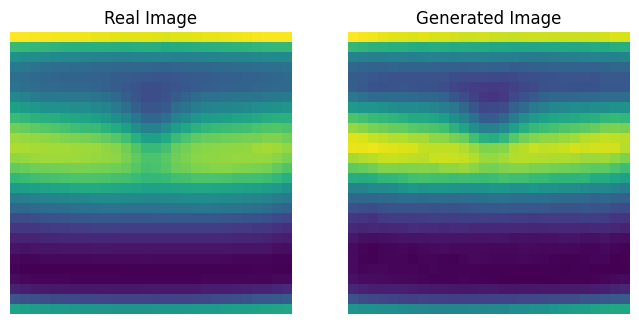

In [ ]:
real_mean_show = (real_mean + 1) / 2
fake_mean_show = (fake_mean + 1) / 2

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.transpose(real_mean_show.numpy(), (1, 2, 0)))
plt.title("Real Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.transpose(fake_mean_show.numpy(), (1, 2, 0)))
plt.title("Generated Image")
plt.axis("off")

plt.show()